# Feature tables: shape and correlation

Looks at the two feature tables side by side and flags features that are
near-duplicates of another (|r| >= threshold), so they can be dropped.

- Table 1: `feature_store_monthly`
- Table 2: `feature_store_monthly_v2` (keys, target, balance lags, `prev_1m_txn_count`,
  `prev_1m_distinct_merchants`, `accounts_held` + derived features, written by
  `src/feature_engineering_v2/features_second.py`)

In [1]:
# Makes `import src...` work from inside notebooks/ by putting the repo root
# on the path. Only needed in the notebook: the container sets PYTHONPATH=/app.
import sys
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams["axes.grid"] = False

In [2]:
from src.config.config import load_config
from src.data.db_link import check_connection, load_dataframe

check_connection()
config = load_config()

CORR_THRESHOLD = config["feature_selection"]["redundancy_threshold"]
TARGET = config["data"]["target_column"]
ID = config["data"]["id_column"]
NON_FEATURES = {ID, "date", TARGET}
print("threshold:", CORR_THRESHOLD)

threshold: 0.95


## Part 1 — `feature_store_monthly`

In [3]:
df1 = load_dataframe("SELECT * FROM feature_store_monthly")
df1 = df1.rename(columns={"month": "date"})
df1["date"] = pd.to_datetime(df1["date"])

# Postgres numeric arrives as Decimal in an object column; make it float.
feat1 = [c for c in df1.columns if c not in NON_FEATURES]
df1[feat1 + [TARGET]] = df1[feat1 + [TARGET]].apply(pd.to_numeric, errors="coerce")

print("shape:", df1.shape)
print("features:", len(feat1))
print("users:", df1[ID].nunique())
print("months:", df1["date"].min().date(), "->", df1["date"].max().date())
nulls = df1.isna().sum()
print()
print("nulls:")
print(nulls[nulls > 0] if nulls.any() else "none")

shape: (6450, 28)
features: 25
users: 150
months: 2022-01-01 -> 2025-07-01

nulls:
prev_1m_closing_balance_usd             150
prev_2m_closing_balance_usd             300
prev_3m_closing_balance_usd             450
roll3_mean_closing_balance_usd          450
roll3_std_closing_balance_usd           450
delta_prev_1m_2m_closing_balance_usd    300
prev_1m_total_credited_usd              150
prev_1m_total_debited_usd               150
prev_1m_net_flow_usd                    150
roll3_mean_total_credited_usd           450
roll3_mean_total_debited_usd            450
roll3_mean_net_flow_usd                 450
prev_1m_txn_count                       150
prev_1m_distinct_merchants              150
prev_1m_total_spend_usd                 150
prev_1m_spend_groceries_usd             150
prev_1m_spend_dining_usd                150
prev_1m_spend_retail_usd                150
prev_1m_spend_cash_atm_usd              150
prev_1m_spend_transport_usd             150
prev_1m_spend_bills_usd              

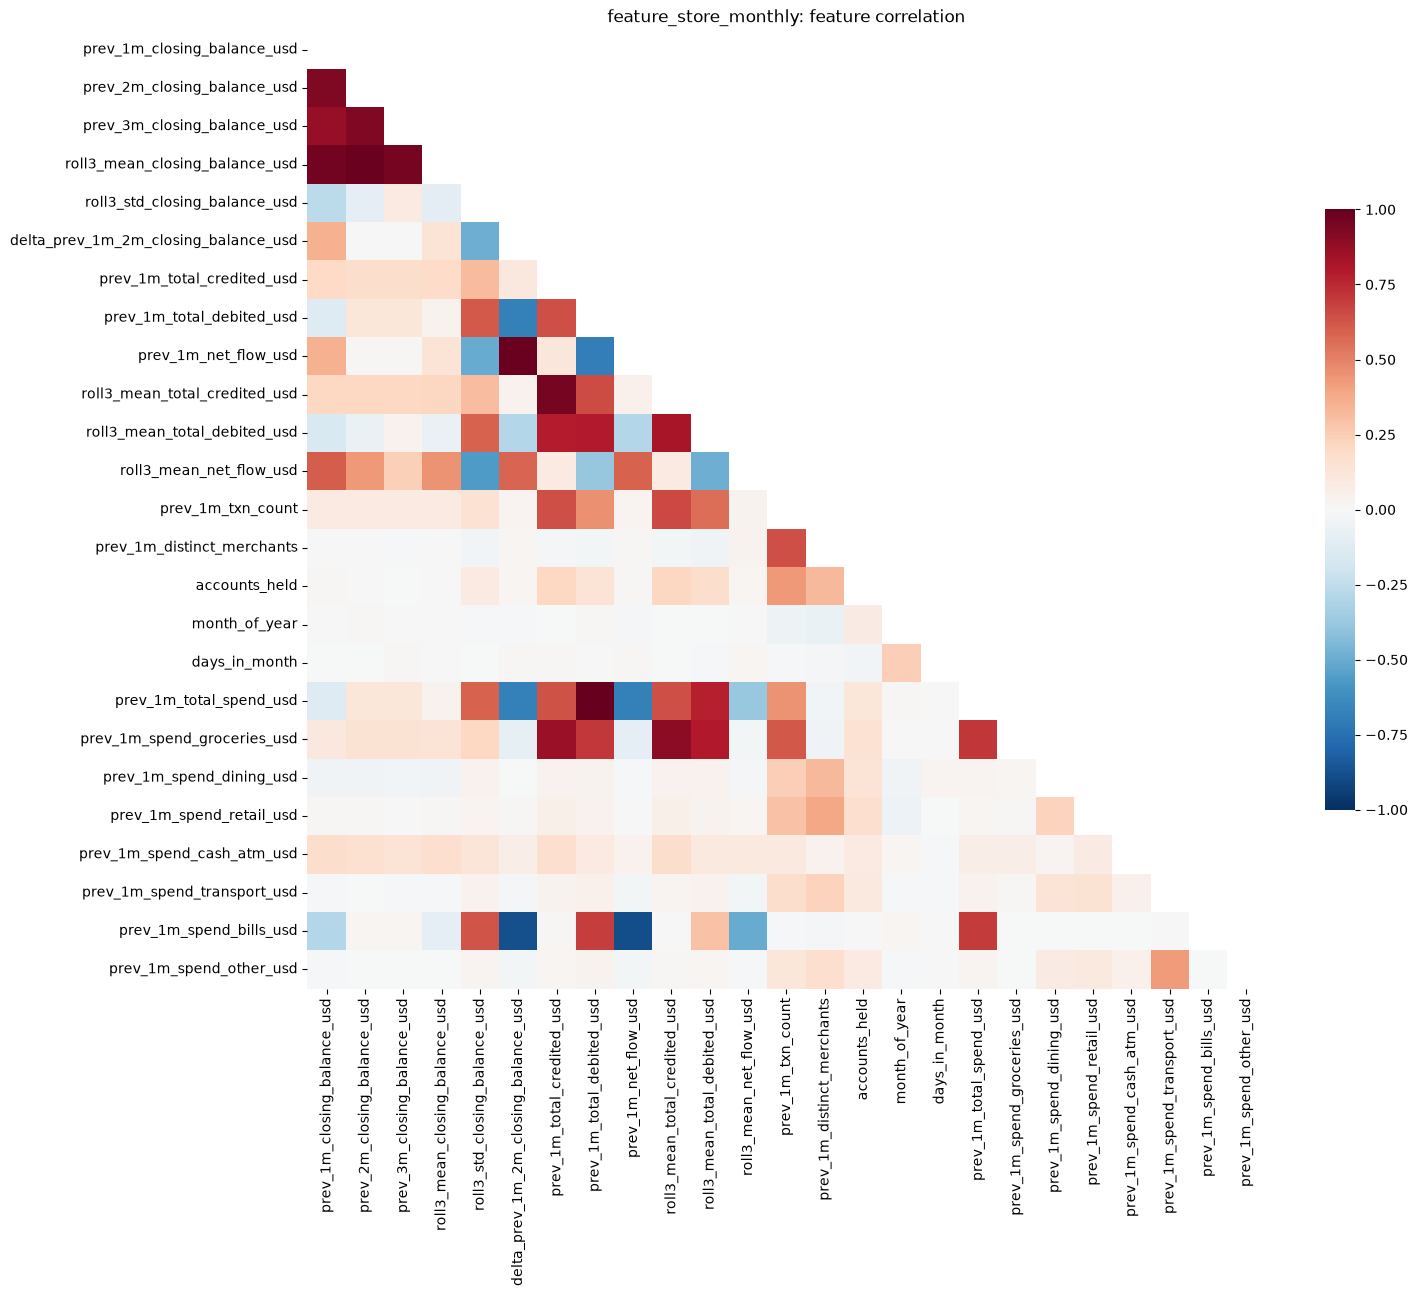

In [4]:
corr1 = df1[feat1].corr()

# Lower triangle only: the upper half is the same numbers mirrored.
mask = np.triu(np.ones_like(corr1, dtype=bool))
fig, ax = plt.subplots(figsize=(0.45 * len(feat1) + 4, 0.4 * len(feat1) + 3))
sns.heatmap(corr1, mask=mask, cmap="RdBu_r", vmin=-1, vmax=1, square=True,
            cbar_kws={"shrink": 0.6}, ax=ax)
ax.set_title("feature_store_monthly: feature correlation")
plt.tight_layout()
plt.show()

In [5]:
# Pairs above the threshold, strongest first. Walking them in that order,
# drop whichever of the pair is less correlated with the target, unless one
# of them has already been dropped by a stronger pair.
target_corr1 = df1[feat1].corrwith(df1[TARGET]).abs()

pairs = (
    corr1.where(np.tril(np.ones_like(corr1, dtype=bool), k=-1))
    .stack()
    .rename("r")
    .reset_index()
    .rename(columns={"level_0": "feature_a", "level_1": "feature_b"})
)
pairs = pairs[pairs["r"].abs() >= CORR_THRESHOLD]
pairs = pairs.reindex(pairs["r"].abs().sort_values(ascending=False).index)

drop_1 = []
suggested = []
for a, b in zip(pairs["feature_a"], pairs["feature_b"]):
    if a in drop_1 or b in drop_1:
        suggested.append("-")
        continue
    loser = a if target_corr1[a] < target_corr1[b] else b
    drop_1.append(loser)
    suggested.append(loser)
pairs["drop"] = suggested
pairs["|r| a~target"] = pairs["feature_a"].map(target_corr1).round(3)
pairs["|r| b~target"] = pairs["feature_b"].map(target_corr1).round(3)

print(f"{len(pairs)} pairs with |r| >= {CORR_THRESHOLD}")
print("drop_1 =", drop_1)
pairs.round(3).reset_index(drop=True)

6 pairs with |r| >= 0.95
drop_1 = ['prev_1m_total_debited_usd', 'prev_1m_net_flow_usd', 'prev_2m_closing_balance_usd', 'roll3_mean_closing_balance_usd', 'prev_1m_total_credited_usd']


,feature_a,feature_b,r,drop,|r| a~target,|r| b~target
0,prev_1m_total_spend_usd,prev_1m_total_debited_usd,0.992,prev_1m_total_debited_usd,0.118,0.117
1,prev_1m_net_flow_usd,delta_prev_1m_2m_closing_balance_usd,0.985,prev_1m_net_flow_usd,0.335,0.335
2,roll3_mean_closing_balance_usd,prev_2m_closing_balance_usd,0.984,prev_2m_closing_balance_usd,0.911,0.884
3,roll3_mean_closing_balance_usd,prev_1m_closing_balance_usd,0.967,roll3_mean_closing_balance_usd,0.911,0.944
4,roll3_mean_closing_balance_usd,prev_3m_closing_balance_usd,0.958,-,0.911,0.815
5,roll3_mean_total_credited_usd,prev_1m_total_credited_usd,0.956,prev_1m_total_credited_usd,0.200,0.193


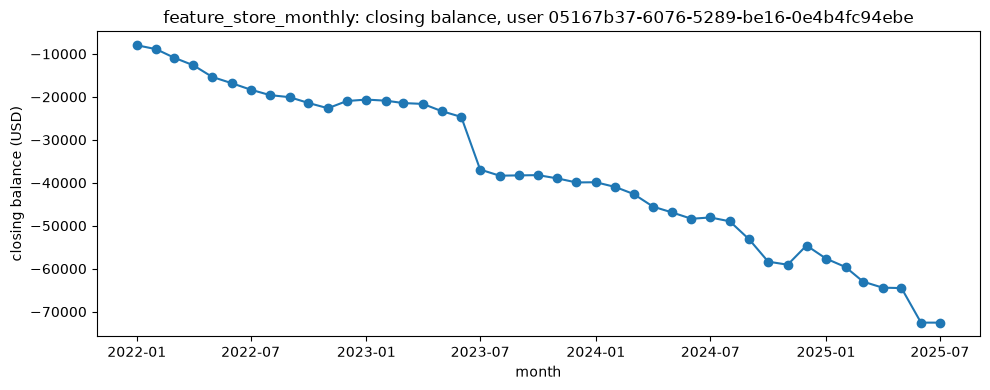

In [6]:
# Change USER_ID_1 to look at someone else; default is the longest history.
USER_ID_1 = df1[ID].value_counts().idxmax()

u = df1[df1[ID] == USER_ID_1].sort_values("date")
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(u["date"], u[TARGET], marker="o")
ax.set_title(f"feature_store_monthly: closing balance, user {USER_ID_1}")
ax.set_xlabel("month")
ax.set_ylabel("closing balance (USD)")
plt.tight_layout()
plt.show()

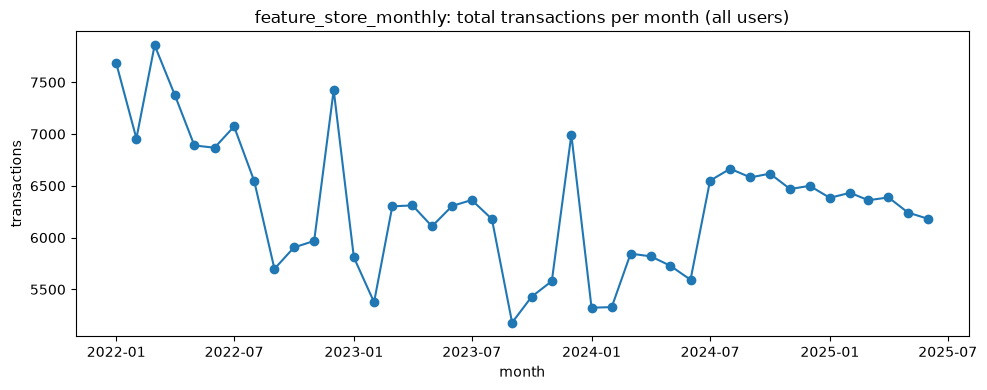

In [7]:
# prev_1m_txn_count on month M is the count for month M-1, so shift the
# axis back one month to put each total on the month it happened.
# min_count=1 so the first month (no previous month, all NaN) drops out
# instead of showing up as a fake zero.
monthly = df1.groupby("date")["prev_1m_txn_count"].sum(min_count=1).dropna()
monthly.index = monthly.index - pd.DateOffset(months=1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly.index, monthly.values, marker="o")
ax.set_title("feature_store_monthly: total transactions per month (all users)")
ax.set_xlabel("month")
ax.set_ylabel("transactions")
plt.tight_layout()
plt.show()

## Part 2 — `feature_store_monthly_v2`

In [8]:
df2 = load_dataframe("SELECT * FROM feature_store_monthly_v2")
df2["date"] = pd.to_datetime(df2["date"])

# Fail here, not three cells down, if the table predates the raw counts.
RAW_V2 = ["prev_1m_txn_count", "prev_1m_distinct_merchants", "accounts_held"]
missing = [c for c in RAW_V2 if c not in df2.columns]
assert not missing, f"{missing} not in feature_store_monthly_v2; rerun features_second.py"

# Postgres numeric arrives as Decimal in an object column; make it float.
feat2 = [c for c in df2.columns if c not in NON_FEATURES]
df2[feat2 + [TARGET]] = df2[feat2 + [TARGET]].apply(pd.to_numeric, errors="coerce")

print("shape:", df2.shape)
print("features:", len(feat2))
print("users:", df2[ID].nunique())
print("months:", df2["date"].min().date(), "->", df2["date"].max().date())
nulls = df2.isna().sum()
print()
print("nulls:")
print(nulls[nulls > 0] if nulls.any() else "none")

shape: (6450, 25)
features: 22
users: 150
months: 2022-01-01 -> 2025-07-01

nulls:
prev_1m_closing_balance_usd    150
prev_2m_closing_balance_usd    300
prev_3m_closing_balance_usd    450
mom_growth_1_2                 359
mom_growth_2_3                 509
growth_3                       509
ratio_balance_to_roll3         496
cv_balance_roll3               496
ratio_credited_to_debited      417
net_flow_to_balance            209
ratio_net_flow_to_roll3        877
share_spend_groceries          420
share_spend_dining             420
share_spend_retail             420
share_spend_cash_atm           420
share_spend_transport          420
share_spend_bills              420
share_spend_other              420
spend_to_balance               209
avg_debit_per_txn              230
dtype: int64


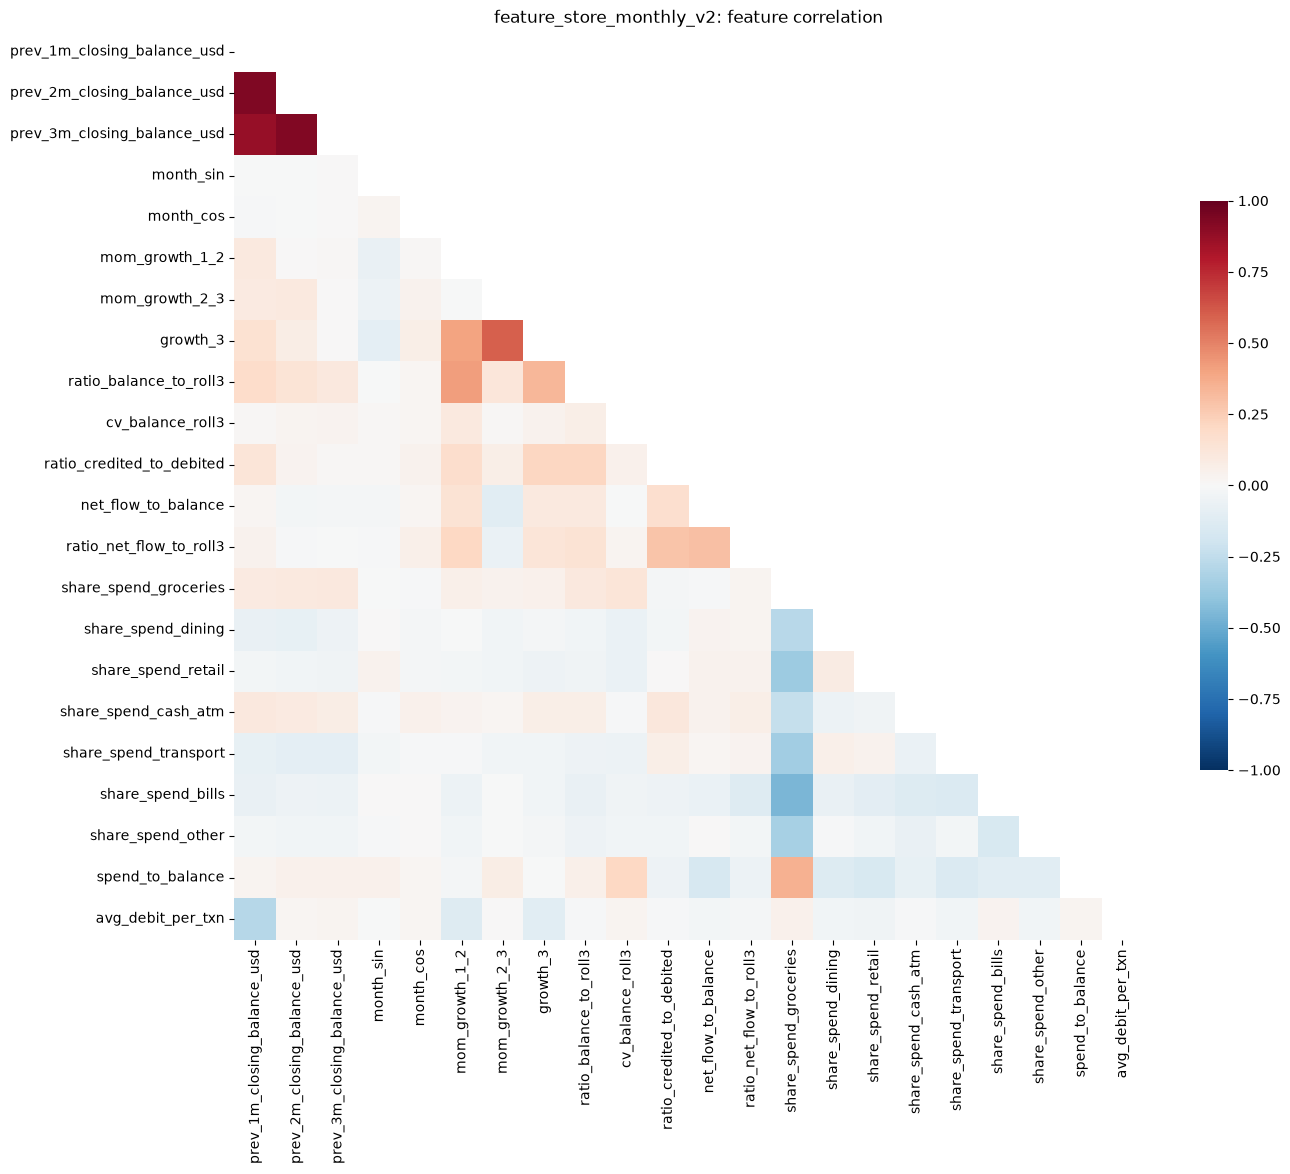

In [9]:
corr2 = df2[feat2].corr()

# Lower triangle only: the upper half is the same numbers mirrored.
mask = np.triu(np.ones_like(corr2, dtype=bool))
fig, ax = plt.subplots(figsize=(0.45 * len(feat2) + 4, 0.4 * len(feat2) + 3))
sns.heatmap(corr2, mask=mask, cmap="RdBu_r", vmin=-1, vmax=1, square=True,
            cbar_kws={"shrink": 0.6}, ax=ax)
ax.set_title("feature_store_monthly_v2: feature correlation")
plt.tight_layout()
plt.show()

In [10]:
# Pairs above the threshold, strongest first. Walking them in that order,
# drop whichever of the pair is less correlated with the target, unless one
# of them has already been dropped by a stronger pair.
target_corr2 = df2[feat2].corrwith(df2[TARGET]).abs()

pairs = (
    corr2.where(np.tril(np.ones_like(corr2, dtype=bool), k=-1))
    .stack()
    .rename("r")
    .reset_index()
    .rename(columns={"level_0": "feature_a", "level_1": "feature_b"})
)
pairs = pairs[pairs["r"].abs() >= CORR_THRESHOLD]
pairs = pairs.reindex(pairs["r"].abs().sort_values(ascending=False).index)

drop_2 = []
suggested = []
for a, b in zip(pairs["feature_a"], pairs["feature_b"]):
    if a in drop_2 or b in drop_2:
        suggested.append("-")
        continue
    loser = a if target_corr2[a] < target_corr2[b] else b
    drop_2.append(loser)
    suggested.append(loser)
pairs["drop"] = suggested
pairs["|r| a~target"] = pairs["feature_a"].map(target_corr2).round(3)
pairs["|r| b~target"] = pairs["feature_b"].map(target_corr2).round(3)

print(f"{len(pairs)} pairs with |r| >= {CORR_THRESHOLD}")
print("drop_2 =", drop_2)
pairs.round(3).reset_index(drop=True)

0 pairs with |r| >= 0.95
drop_2 = []


,feature_a,feature_b,r,drop,|r| a~target,|r| b~target


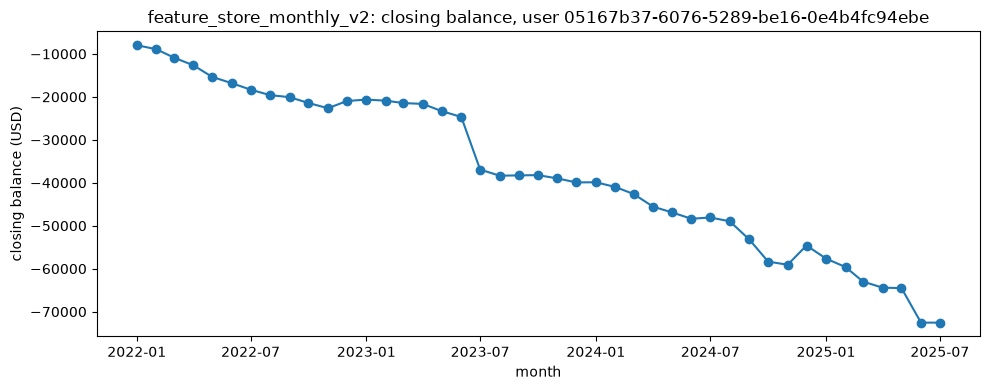

In [11]:
# Change USER_ID_2 to look at someone else; default is the longest history.
USER_ID_2 = df2[ID].value_counts().idxmax()

u = df2[df2[ID] == USER_ID_2].sort_values("date")
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(u["date"], u[TARGET], marker="o")
ax.set_title(f"feature_store_monthly_v2: closing balance, user {USER_ID_2}")
ax.set_xlabel("month")
ax.set_ylabel("closing balance (USD)")
plt.tight_layout()
plt.show()

In [12]:
# prev_1m_txn_count on month M is the count for month M-1, so shift the
# axis back one month to put each total on the month it happened.
# min_count=1 so the first month (no previous month, all NaN) drops out
# instead of showing up as a fake zero.
monthly = df2.groupby("date")["prev_1m_txn_count"].sum(min_count=1).dropna()
monthly.index = monthly.index - pd.DateOffset(months=1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly.index, monthly.values, marker="o")
ax.set_title("feature_store_monthly_v2: total transactions per month (all users)")
ax.set_xlabel("month")
ax.set_ylabel("transactions")
plt.tight_layout()
plt.show()

KeyError: 'Column not found: prev_1m_txn_count'

## Summary

In [ ]:
print("Table 1 shape:", df1.shape)
print("Table 2 shape:", df2.shape)
print()
print("only in table 1:", sorted(set(feat1) - set(feat2)))
print("only in table 2:", sorted(set(feat2) - set(feat1)))
print()
print("drop_1 =", drop_1)
print("drop_2 =", drop_2)